<a href="https://colab.research.google.com/github/Maryam-Skaik/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

- Author: Maryam Refaa Haidar Skaik

## Project Overview

## Load and Inspect Data

In [1]:
# import needed libraries
import pandas as pd

In [2]:
# read data and review first 5 records
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/Course 1/Week 2/Data/sales_predictions_2023.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
# review summary of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Cleaning

### 1) How many rows and columns?

In [4]:
df.shape

(8523, 12)

- df contains 8523 rows and 12 columns

### 2) What are the datatypes of each variable?

In [5]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


No need to change datatypes of columns

### 3) Are there duplicates?

In [6]:
df.duplicated().sum()

np.int64(0)

Also for duplicates, there is no duplicates in our dataset

### 4) Identify missing values.

In [7]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


We note missing values in Item_Weight and Outlet_Size

### 5) Address the missing values by using a placeholder value.

first, for Item_Weight, since it's a number, we will fill missing values with -1

In [8]:
df['Item_Weight'] = df['Item_Weight'].fillna(-1)

Check missing values

In [9]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Now, for Outlet_Size, it's categorical, so will fill missing values with 'MISSING'

In [10]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')

### 6) Confirm that there are no missing values after addressing them.

Check missing values *again*

In [11]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


### 7) Find and fix any inconsistent categories of data

Check columns uniqueness

In [12]:
df.nunique()

,0
Item_Identifier,1559
Item_Weight,416
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,4
Outlet_Location_Type,3


Note: Item_Fat_Content, Outlet_Size, Outlet_Location_Type, Outlet_Type are categorical

In [13]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [14]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(['Low Fat', 'LF'], 'low fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(['Regular', 'reg'], 'regular')

Recheck values

In [15]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
low fat,5517
regular,3006


Next, Outlet_Size

In [16]:
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


No need to any replacement

Next, Outlet_Location_Type

In [17]:
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


Also, no need to replacement here

Then, Outlet_Type

In [18]:
df['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


So, we finished fixing inconsistent categories

### 8) For any numerical columns, obtain the summary statistics of each

In [19]:
numeric_columns = df.select_dtypes('number').columns

df[numeric_columns]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.300,0.016047,249.8092,1999,3735.1380
1,5.920,0.019278,48.2692,2009,443.4228
2,17.500,0.016760,141.6180,1999,2097.2700
3,19.200,0.000000,182.0950,1998,732.3800
4,8.930,0.000000,53.8614,1987,994.7052
...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,2778.3834
8519,8.380,0.046982,108.1570,2002,549.2850
8520,10.600,0.035186,85.1224,2004,1193.1136
8521,7.210,0.145221,103.1332,2009,1845.5976


In [20]:
df[numeric_columns].agg(['max', 'min', 'mean'])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
min,-1.000000,0.000000,31.290000,1985.000000,33.290000
mean,10.478936,0.066132,140.992782,1997.831867,2181.288914


## Project 1 – Part 3 Tasks (Exploratory Data Visualization)

### Import visualization libraries.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

### Histograms (Distribution of Numerical Features)

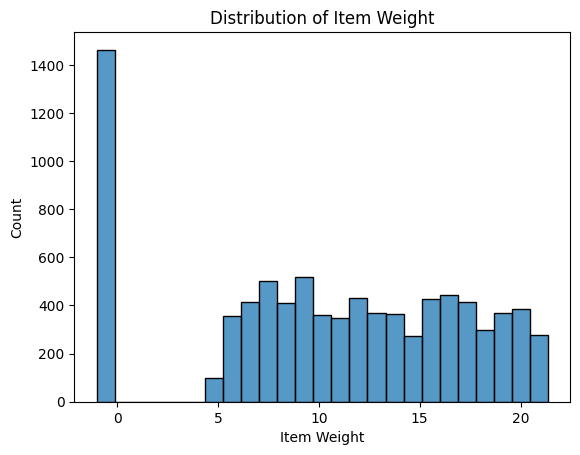

In [22]:
ax = sns.histplot(data=df, x='Item_Weight')
ax.set_title("Distribution of Item Weight")
ax.set_xlabel("Item Weight");

The histogram shows a predominant spike at −1, identifying it as the most frequent value and signaling a significant amount of missing data in the Item_Weight field. while the valid item weights are distributed relatively uniformly between 5 and 21.

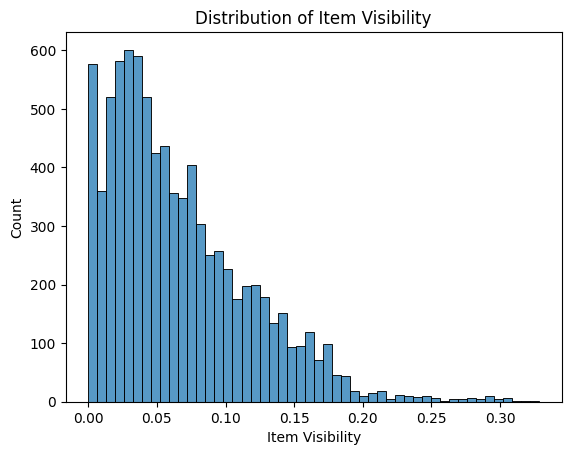

In [23]:
ax = sns.histplot(data=df, x='Item_Visibility')
ax.set_title("Distribution of Item Visibility")
ax.set_xlabel("Item Visibility");

The histogram for Item_Visibility shows a positively skewed (right-skewed) distribution, where the majority of items have low visibility scores and a long tail extends toward higher values, indicating that most products are not prominently displayed.

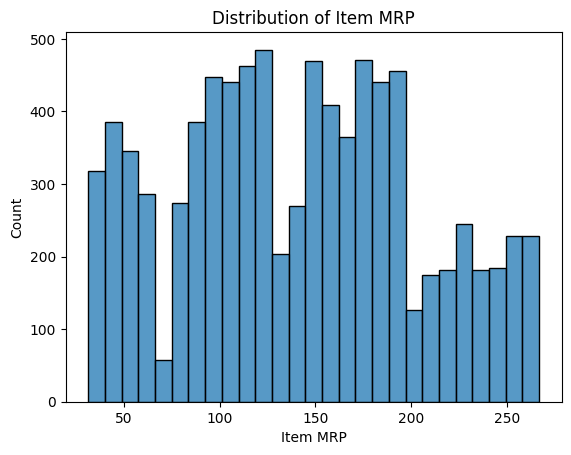

In [24]:
ax = sns.histplot(data=df, x='Item_MRP')
ax.set_title("Distribution of Item MRP")
ax.set_xlabel("Item MRP");

The histogram for Item_MRP reveals a multimodal distribution with four distinct clusters of price ranges, indicating that the products are naturally grouped into different price tiers rather than following a single bell curve.

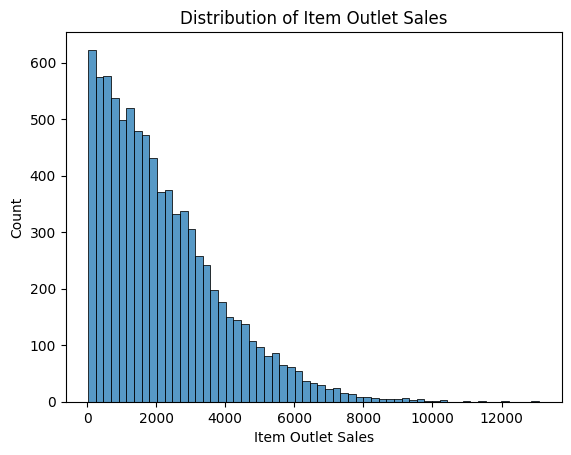

In [25]:
ax = sns.histplot(data=df, x='Item_Outlet_Sales')
ax.set_title("Distribution of Item Outlet Sales")
ax.set_xlabel("Item Outlet Sales");

The histogram for Item_Outlet_Sales shows a highly right-skewed (positive) distribution, indicating that while most items generate lower sales figures, there is a long tail of high-performing products contributing to significant revenue.

### Boxplots (Statistical Summary)

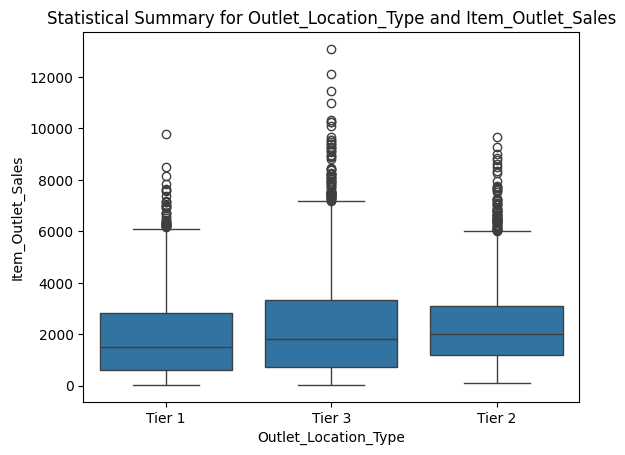

In [34]:
ax = sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales')
ax.set_title("Statistical Summary for Outlet_Location_Type and Item_Outlet_Sales");

The boxplot indicates that Tier 2 and Tier 3 locations generally achieve higher median sales than Tier 1, while all three categories exhibit a significant number of outliers representing high-revenue transactions, particularly in Tier 3.

### Countplots

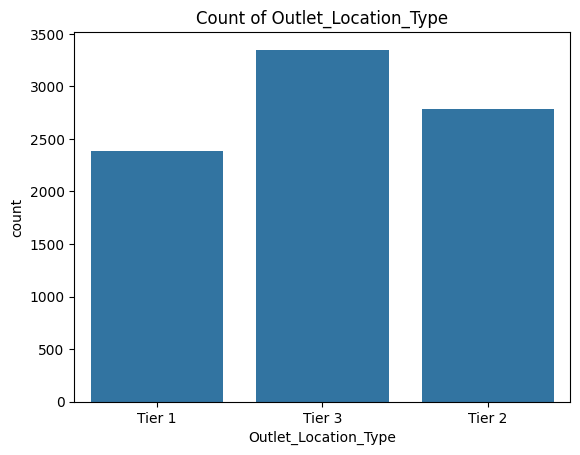

In [37]:
ax = sns.countplot(data=df, x='Outlet_Location_Type')
ax.set_title('Count of Outlet Location Type');

The countplot shows that Tier 3 locations are the most frequent in the dataset, followed by Tier 2 and Tier 1, indicating that the data is primarily collected from outlets in Tier 3 areas.

### Correlation Heatmap

In [38]:
corr = df.corr(numeric_only=True)
corr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.079371,0.022367,0.537341,-0.055461
Item_Visibility,-0.079371,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.022367,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,0.537341,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,-0.055461,-0.128625,0.567574,-0.049135,1.000000


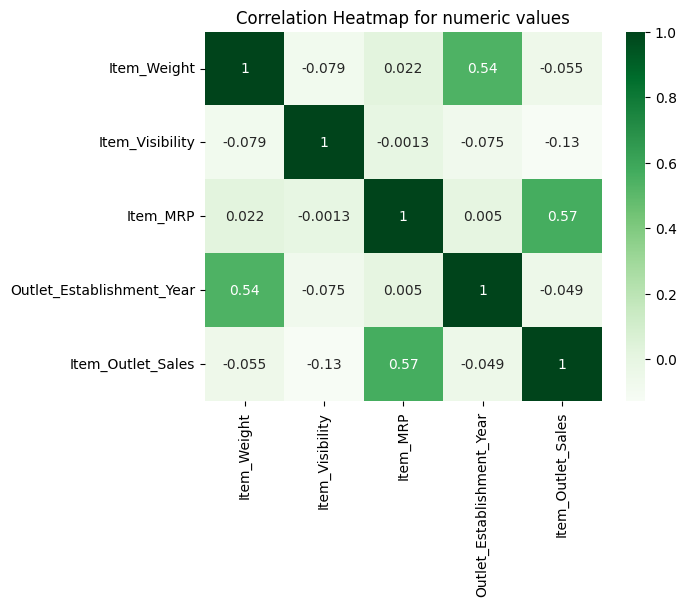

In [42]:
ax = sns.heatmap(corr, cmap='Greens', annot=True)
ax.set(title='Correlation Heatmap for numeric values');

The correlation heatmap identifies Item_MRP as the most significant driver of Item_Outlet_Sales with a moderate positive correlation of $0.57$, suggesting that higher-priced items generally yield higher total revenue. Interestingly, there is a notable moderate correlation ($0.54$) between Item_Weight and Outlet_Establishment_Year, which may indicate shifts in how data was recorded or items were stocked over time rather than a direct physical relationship. Conversely, Item_Visibility shows a weak negative correlation ($-0.13$) with sales, implying that increased visibility does not automatically translate to higher sales volume in this dataset. Most other variables remain largely independent, indicating that the features are not redundant and provide distinct types of information for further analysis.